In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
flights = pd.read_csv("../data/cleaned/cleaned_flights.csv")
flights.head()

,carrier_code,date,flight_number,tail_number,destination_airport,scheduled_departure_time,actual_departure_time,scheduled_elapsed_time_minutes,actual_elapsed_time_minutes,departure_delay_minutes,...,delay_carrier_minutes,delay_weather_minutes,delay_national_aviation_system_minutes,delay_security_minutes,delay_late_aircraft_arrival_minutes,origin_airport,month,day_of_week,departure_hour,delayed_15
0,B6,2025-01-01,100.0,N2188J,FLL,10:43,10:34,302.0,282.0,-9.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Wednesday,10,0
1,B6,2025-01-01,200.0,N982JB,FLL,23:05,23:12,291.0,288.0,7.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Wednesday,23,0
2,B6,2025-01-01,288.0,N2156J,BOS,11:05,10:52,325.0,316.0,-13.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Wednesday,11,0
3,B6,2025-01-01,388.0,N2180J,BOS,20:39,20:32,322.0,298.0,-7.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Wednesday,20,0
4,B6,2025-01-01,424.0,N2165J,JFK,06:35,06:21,324.0,296.0,-14.0,...,0.0,0.0,0.0,0.0,0.0,LAX,1,Wednesday,6,0


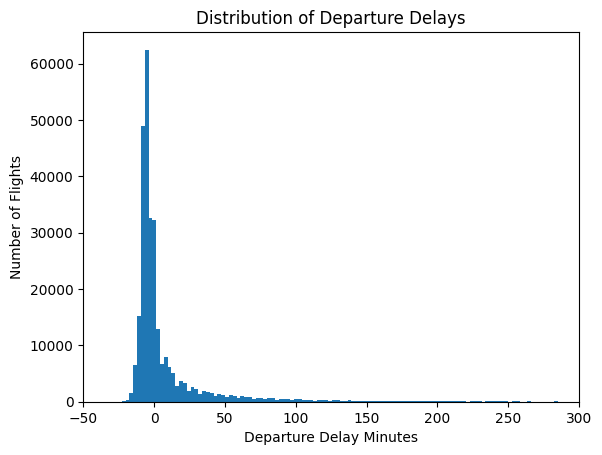

In [4]:
plt.hist(flights["departure_delay_minutes"], bins = 1000)

plt.xlim(-50, 300)
plt.xlabel("Departure Delay Minutes")
plt.ylabel("Number of Flights")
plt.title("Distribution of Departure Delays")
plt.show()

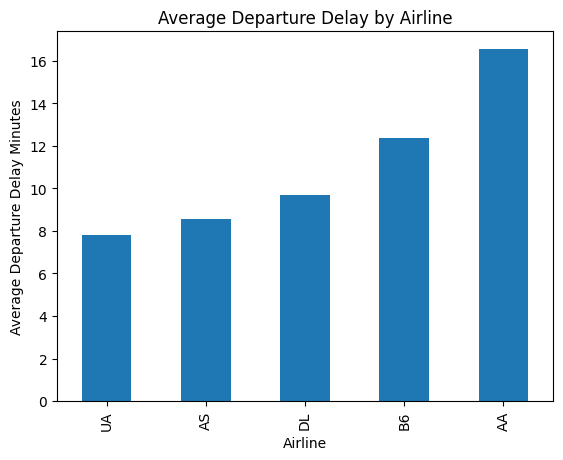

In [5]:
airline_delays = (
    flights
    .groupby("carrier_code")
    ["departure_delay_minutes"]
    .mean()
    .sort_values()
)

airline_delays.plot(kind="bar")
plt.xlabel("Airline")
plt.ylabel("Average Departure Delay Minutes")
plt.title("Average Departure Delay by Airline")

plt.show()

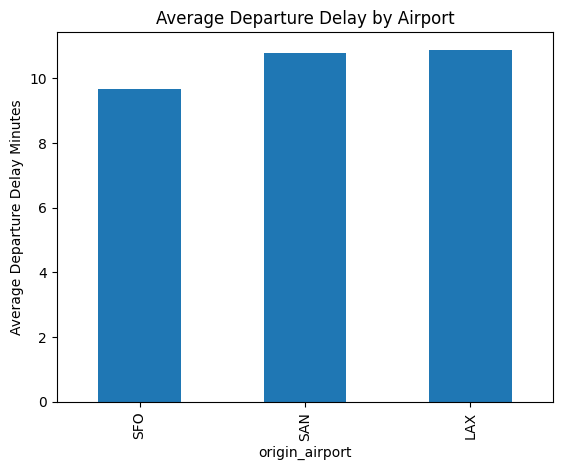

In [6]:
airport_delays = (
    flights
    .groupby("origin_airport")
    ["departure_delay_minutes"]
    .mean()
    .sort_values()
)

airport_delays.plot(kind="bar")

plt.ylabel("Average Departure Delay Minutes")
plt.title("Average Departure Delay by Airport")

plt.show()

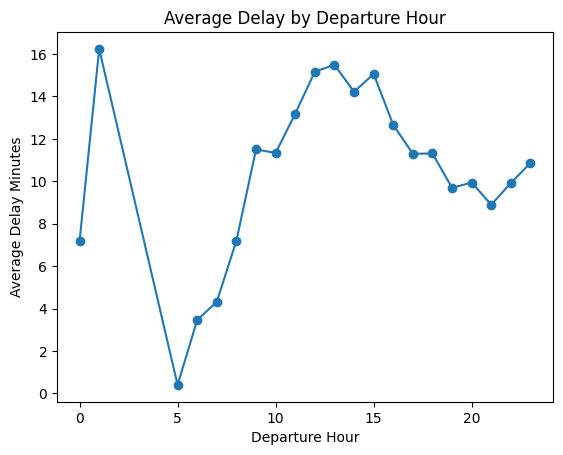

In [7]:
hourly_delays = (flights.groupby("departure_hour")["departure_delay_minutes"].mean())

plt.plot(hourly_delays.index, hourly_delays.values, marker="o")

plt.xlabel("Departure Hour")
plt.ylabel("Average Delay Minutes")
plt.title("Average Delay by Departure Hour")

plt.show()

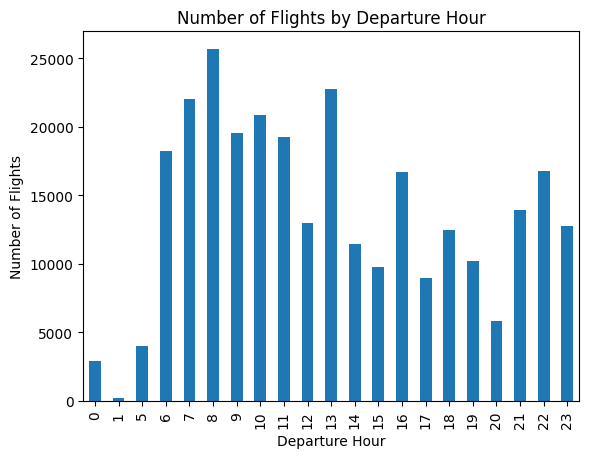

In [8]:
flights["departure_hour"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Departure Hour")
plt.ylabel("Number of Flights")
plt.title("Number of Flights by Departure Hour")

plt.show()

The unusually low average delay around 5 AM is likely due to the relatively small number of flights departing during that hour. With fewer observations, the average delay is more sensitive to random variation than during busier periods of the day.

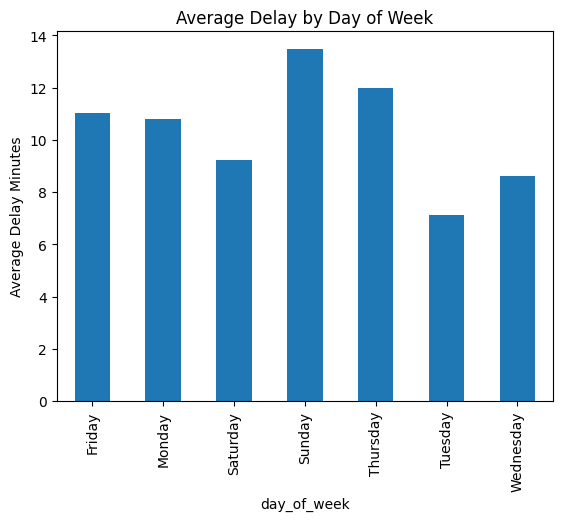

In [11]:
weekday_delay = (flights.groupby("day_of_week")["departure_delay_minutes"].mean())

weekday_delay.plot(kind = "bar")

plt.title("Average Delay by Day of Week")
plt.ylabel("Average Delay Minutes")
plt.show()

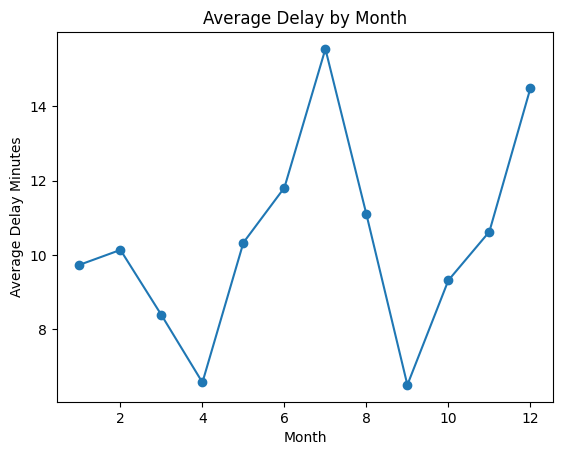

In [12]:
monthly_delay = (flights.groupby("month")["departure_delay_minutes"].mean())

plt.plot(monthly_delay.index, monthly_delay.values, marker="o")

plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay Minutes")
plt.show()